# Big Data Project - Part A

<img src="https://tinyurl.com/Big-Data-Project-Theme-Pic" />


### *Imports*

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from IPython.display import SVG
from graphviz import Source
from IPython.display import display
import numpy as np

In [2]:
!pip install graphviz

### *Data Loading*

In [3]:
churn_df = pd.read_csv(r"C:\Users\Lera\Downloads\churn.csv")
churn_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


#### *Renaming columns to lowercase and separating concatenated column names*

In [4]:
churn_df.columns = churn_df.columns.str.replace("ID", "Id").str.replace("TV", "Tv")
churn_df.columns = [
    re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower()
    for col in churn_df.columns
]

churn_df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

### *Missing Values Check*

In [5]:
churn_df.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

### *Data Types Validation*

In [6]:
churn_df.dtypes

customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges         object
churn                 object
dtype: object

#### *Identifying Misclassified Features*
The validation above revealed that `total_charges` feature was misclassified as `str`,

highlighting a potential data quality issue that could negatively impact calculations and model accuracy.

#### *Resolving Data Type Issue*

**Step 1:**
Converting `total_charges` to numeric while coercing invalid values to `NaN`

In [7]:
churn_df['total_charges'] = pd.to_numeric(churn_df['total_charges'], errors='coerce')

**Step 2:**
Checking if missing values in `total_charges` are related to new customers (`tenure = 0`).

In [8]:
churn_df.loc[churn_df['total_charges'].isna(), ['total_charges', 'tenure']]

,total_charges,tenure
488,NaN,0
753,NaN,0
936,NaN,0
1082,NaN,0
1340,NaN,0
3331,NaN,0
3826,NaN,0
4380,NaN,0
5218,NaN,0
6670,NaN,0


Unbelievable! all missing values are indeed connected to customers with `tenure = 0`

**Step 3:**
Imputing missing `total_charges` values with `0.00` based on the connection found above

In [9]:
churn_df['total_charges'] = churn_df['total_charges'].fillna(0.00)

**Step 4:**
Verifying that no missing values remain in the dataset ✔

In [10]:
churn_df.isna().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

### *Data Inspection & Uniqueness Check*

In [11]:
churn_df.shape

(7043, 21)

#### *1. Low-Cardinality Features*
##### *(Up To 4 Unique Values)*

In [12]:
for col in churn_df.columns:
    unique_count = churn_df[col].nunique()

    match unique_count:
        case 2 | 3 | 4:
            print(f'The following column has {unique_count} unique values:')
            print(f'Column: {churn_df[col].value_counts()}\n----------------------')

The following column has 2 unique values:
Column: gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------
The following column has 2 unique values:
Column: senior_citizen
0    5901
1    1142
Name: count, dtype: int64
----------------------
The following column has 2 unique values:
Column: partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------
The following column has 2 unique values:
Column: dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------
The following column has 2 unique values:
Column: phone_service
Yes    6361
No      682
Name: count, dtype: int64
----------------------
The following column has 3 unique values:
Column: multiple_lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------
The following column has 3 unique values:
Column: internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count,

#### *2. High-Cardinality Features*
##### *(More Than 4 Unique Values)*

In [13]:
for col in churn_df.columns:
    if churn_df[col].nunique() > 4:
        print(
            f"{col}'s column has {churn_df[col].nunique()} unique values ({(churn_df[col].nunique() / churn_df[col].count()):.2%})")

customer_id's column has 7043 unique values (100.00%)
tenure's column has 73 unique values (1.04%)
monthly_charges's column has 1585 unique values (22.50%)
total_charges's column has 6531 unique values (92.73%)


### *Handling High-Cardinality Features*

#### *1. Drop* `customer_id` *Column*

In [14]:
churn_df = churn_df.drop(['customer_id'], axis=1)
churn_df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

#### *2. Grouping* `tenure` *Column*

In [15]:
conditions = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
churn_df['tenure_segment'] = pd.cut(
    churn_df['tenure'],
    bins=conditions,
    labels=labels,
    right=True,
    include_lowest=True
)
churn_df.groupby('tenure_segment', observed=False)['tenure_segment'].count()

tenure_segment
0-12     2186
13-24    1024
25-36     832
37-48     762
49-60     832
61-72    1407
Name: tenure_segment, dtype: int64

### *Categorical Values Unification Prior To Encoding*
##### Unifying `No internet service` / `No phone service` Values Into A Single “No” Category To Avoid Unnecessary Noise

In [16]:
cols = [
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines'
]

for col in cols:
    churn_df[col] = churn_df[col].replace('No internet service', 'No')
    churn_df[col] = churn_df[col].replace('No phone service', 'No')

In [17]:
for col in churn_df.columns:
    if churn_df[col].nunique() == 3:
        print(f'Column:{col} {churn_df[col].unique()}\n')

Column:internet_service ['DSL' 'Fiber optic' 'No']

Column:contract ['Month-to-month' 'One year' 'Two year']



### *Tenure Distribution*
Visualizes how long customers typically stay (in months) and whether the dataset is dominated by new vs long-term customers.

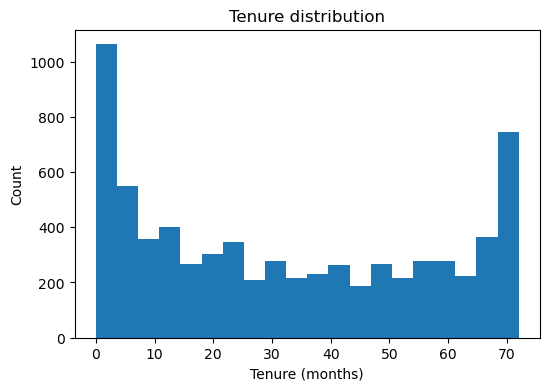

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(churn_df['tenure'], bins=20)
plt.title("Tenure distribution")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

### *Churn Rate By Both Contract & Internet Service Type*


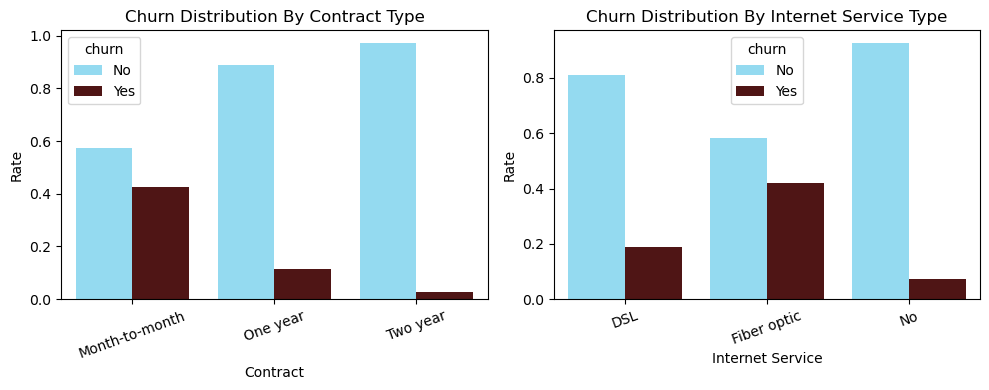

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(['contract', 'internet_service']):
    plot_df = pd.crosstab(churn_df[col], churn_df['churn'], normalize='index') \
        .reset_index() \
        .melt(id_vars=col, var_name='churn', value_name='rate')

    sns.barplot(data=plot_df, x=col, y='rate', hue='churn', ax=ax[i],
                palette={'Yes': '#590B0B', 'No': '#85E2FF'})

    ax[i].set_title(f"Churn Distribution By {col.replace('_', ' ').title()} Type")
    ax[i].set_xlabel(col.replace('_', ' ').title())
    ax[i].set_ylabel("Rate")
    ax[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### *Encoding Categorical Variables*

#### *1. One-Hot Encoding*

In [20]:
categorical_cols = [
    'gender',
    'internet_service',
    'payment_method'
]
churn_df = pd.get_dummies(churn_df, columns=categorical_cols, drop_first=False)

In [21]:
map_cols = ['gender_Female', 'gender_Male',
            'internet_service_DSL', 'internet_service_Fiber optic',
            'internet_service_No', 'payment_method_Bank transfer (automatic)',
            'payment_method_Credit card (automatic)',
            'payment_method_Electronic check', 'payment_method_Mailed check'
            ]
for col in map_cols:
    churn_df[col] = churn_df[col].map({False: 0, True: 1})

#### *2. Ordinal Encoding*

In [22]:
tenure_segment_map = {
    '0-12': 0,
    '13-24': 1,
    '25-36': 2,
    '37-48': 3,
    '49-60': 4,
    '61-72': 5
}

contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}

churn_df['tenure_segment'] = churn_df['tenure_segment'].map(tenure_segment_map)
churn_df['contract'] = churn_df['contract'].map(contract_map)

#### *3. Label Encoding Including Label Target Variable (`churn`) to numeric*

In [23]:
binary_cols = ['churn', 'partner', 'dependents', 'phone_service',
               'multiple_lines', 'online_security', 'online_backup',
               'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
               'paperless_billing'
               ]
for col in binary_cols:
    churn_df[col] = churn_df[col].map({'No': 0, 'Yes': 1})

In [24]:
customers = len(churn_df)
active = (churn_df['churn'] == 0).sum()
left = (churn_df['churn'] == 1).sum()

print(
    f'We have {customers} customers.\n💲 {active} of them are active ({active / customers:.2%})\n🔻 {left} of them are NOT active ({left / customers:.2%})')

We have 7043 customers.
💲 5174 of them are active (73.46%)
🔻 1869 of them are NOT active (26.54%)


#### *Making Sure All Data Types Are Numerical For Our Next Stage*

In [25]:
churn_df.dtypes

senior_citizen                                 int64
partner                                        int64
dependents                                     int64
tenure                                         int64
phone_service                                  int64
multiple_lines                                 int64
online_security                                int64
online_backup                                  int64
device_protection                              int64
tech_support                                   int64
streaming_tv                                   int64
streaming_movies                               int64
contract                                       int64
paperless_billing                              int64
monthly_charges                              float64
total_charges                                float64
churn                                          int64
tenure_segment                              category
gender_Female                                 

In [26]:
churn_df.tenure_segment = churn_df.tenure_segment.astype(int)

##### Renaming columns for convenience
* internet_service = is
* payment_method = pm

In [27]:
churn_df.columns = ['senior', 'partner', 'dependents', 'tenure', 'phone_service',
                    'multiple_lines', 'online_security', 'online_backup',
                    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
                    'contract', 'paperless_billing', 'monthly_charges', 'total_charges',
                    'churn', 'tenure_segment', 'female', 'male',
                    'is_DSL', 'is_fiber_optic',
                    'is_no', 'pm_bank_transfer',
                    'pm_credit_card',
                    'pm_electronic_check', 'pm_mailed_check']

In [28]:
churn_df.to_csv('churn-Part-A.csv')

### *Correlation Heatmap For Finding Strong Connections*
The correlation heatmap suggests `churn` is most associated with customer `tenure`/`contract` type and service-related features (e.g., `fiber optic` and `payment method`)

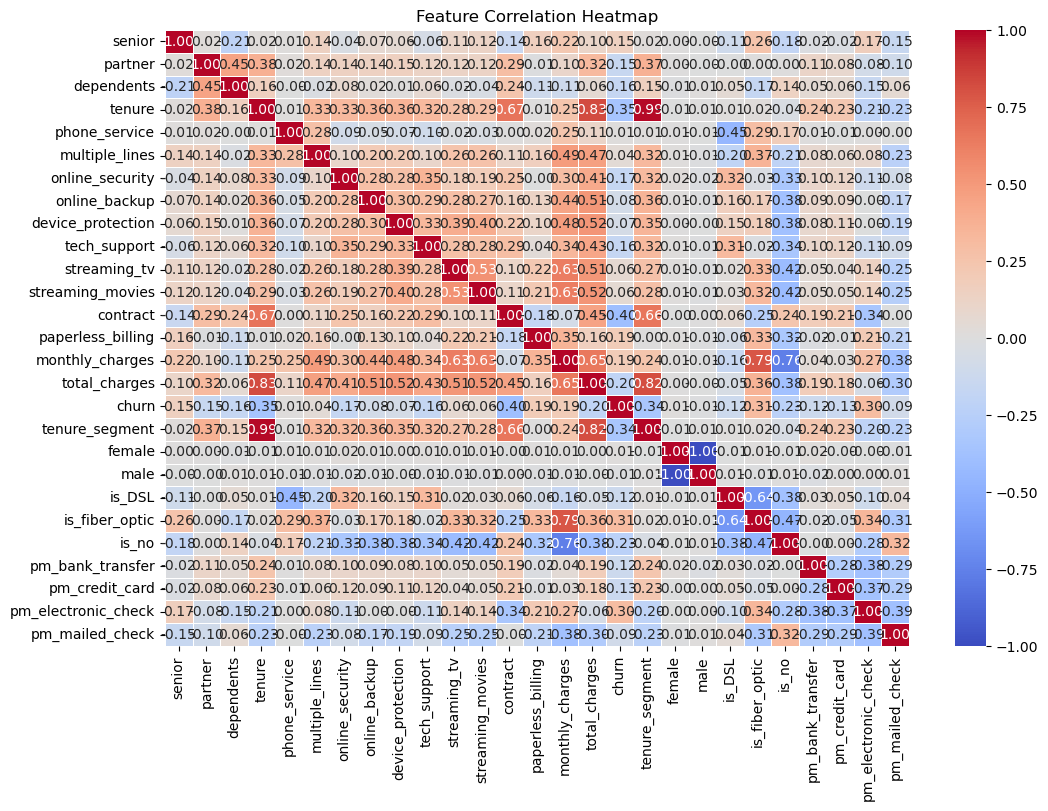

In [29]:
plt.figure(figsize=(12, 8))
sns.heatmap(churn_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### *Train-Test Splitting*

In [30]:
train, test = train_test_split(churn_df, test_size=0.2, random_state=0, shuffle=True)

label = 'churn'
x_train = train.drop(label, axis=1)
y_train = train[label]

x_test = test.drop(label, axis=1)
y_test = test[label]

x_train.shape, x_test.shape, y_train.mean(), y_test.mean()


((5634, 26), (1409, 26), 0.26641817536386225, 0.26117814052519517)

### *Decision Tree*

In [31]:
dt_results = []
for depth in [3, 5, 2, 99]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
    clf.fit(x_train, y_train)
    y_train_pred = clf.predict(x_train)
    y_test_pred = clf.predict(x_test)
    dt_results.append({
        'model': 'DecisionTree',
        'param': f'max_depth={depth}',
        'train_acc': accuracy_score(y_train, y_train_pred),
        'test_acc': accuracy_score(y_test, y_test_pred),
        'estimator': clf
    })
pd.DataFrame([{k: v for k, v in r.items() if k != 'estimator'} for r in dt_results])

,model,param,train_acc,test_acc
0,DecisionTree,max_depth=3,0.792332,0.778566
1,DecisionTree,max_depth=5,0.805999,0.784244
2,DecisionTree,max_depth=2,0.763401,0.758694
3,DecisionTree,max_depth=99,0.997515,0.727466


In [32]:
best_dt = max(dt_results, key=lambda r: r['test_acc'])
best_dt['param'], best_dt['test_acc']

('max_depth=5', 0.7842441447835344)

In [33]:
graph = Source(
    export_graphviz(best_dt['estimator'], feature_names=list(x_train.columns), class_names=['Stayed', 'Churned'],
                    filled=True,
                    max_depth=5))
display(SVG(graph.pipe(format='svg')))


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

### *Random Forest*

In [ ]:
rf_results = []

for n in [100, 200, 150, 50, 10, 9, 8]:
    model = RandomForestClassifier(n_estimators=n, max_depth=3, random_state=1)
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    rf_results.append({
        'model': 'RandomForest',
        'param': f'n_estimators={n}, max_depth=3',
        'train_acc': accuracy_score(y_train, y_train_pred),
        'test_acc': accuracy_score(y_test, y_test_pred),
        'estimator': model
    })

for depth in [5, 7, 9, 21, 100, 3]:
    model = RandomForestClassifier(n_estimators=9, max_depth=depth, random_state=1)
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    rf_results.append({
        'model': 'RandomForest',
        'param': f'n_estimators=9, max_depth={depth}',
        'train_acc': accuracy_score(y_train, y_train_pred),
        'test_acc': accuracy_score(y_test, y_test_pred),
        'estimator': model
    })

pd.DataFrame([{k: v for k, v in r.items() if k != 'estimator'} for r in rf_results]).sort_values('test_acc',
                                                                                                 ascending=False).head(
    10)

,model,param,train_acc,test_acc
8,RandomForest,"n_estimators=9, max_depth=7",0.819844,0.793471
9,RandomForest,"n_estimators=9, max_depth=9",0.855520,0.793471
7,RandomForest,"n_estimators=9, max_depth=5",0.804934,0.787083
5,RandomForest,"n_estimators=9, max_depth=3",0.794640,0.783534
12,RandomForest,"n_estimators=9, max_depth=3",0.794640,0.783534
4,RandomForest,"n_estimators=10, max_depth=3",0.793042,0.782825
6,RandomForest,"n_estimators=8, max_depth=3",0.794995,0.782825
3,RandomForest,"n_estimators=50, max_depth=3",0.793930,0.779986
1,RandomForest,"n_estimators=200, max_depth=3",0.791445,0.778566
0,RandomForest,"n_estimators=100, max_depth=3",0.790202,0.777147


In [ ]:
best_rf = max(rf_results, key=lambda r: r['test_acc'])
best_rf['param'], best_rf['test_acc']

('n_estimators=9, max_depth=7', 0.7934705464868701)

In [ ]:
fi = pd.DataFrame({
    'feature': x_train.columns,
    'importance': best_rf['estimator'].feature_importances_
}).sort_values('importance', ascending=False)

fi.head(15)


,feature,importance
12,contract,0.210003
3,tenure,0.171093
20,is_fiber_optic,0.118806
14,monthly_charges,0.093221
15,total_charges,0.088258
16,tenure_segment,0.076273
24,pm_electronic_check,0.042270
21,is_no,0.037144
13,paperless_billing,0.027171
0,senior,0.015583


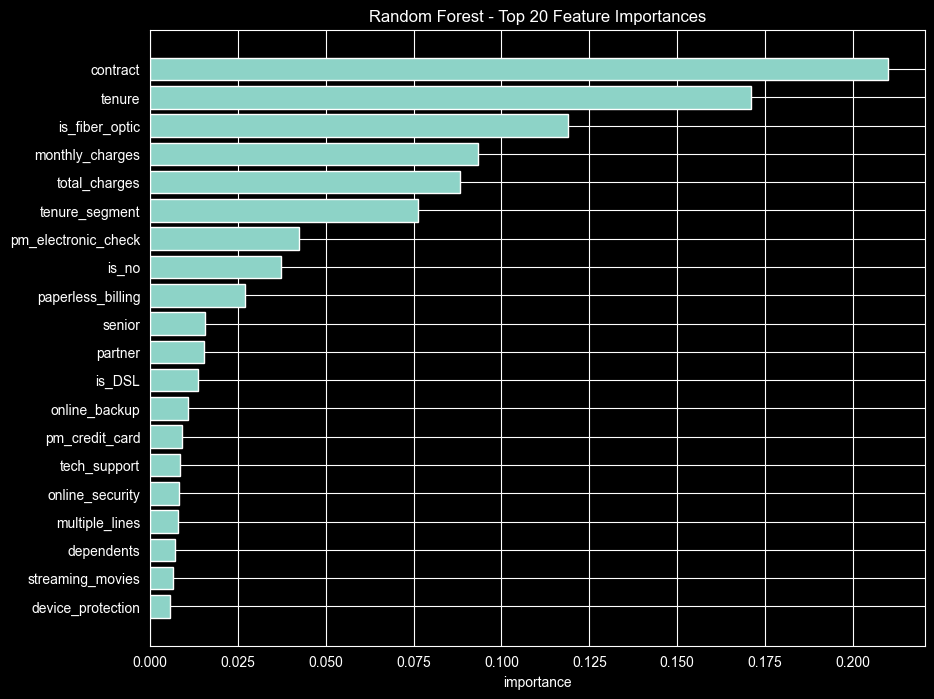

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(fi['feature'].head(20)[::-1], fi['importance'].head(20)[::-1])
plt.title("Random Forest - Top 20 Feature Importances")
plt.xlabel("importance")
plt.show()


### *KNN*

In [ ]:
def run_knn(k_values, x_train, x_test, y_train, y_test, scaled=False):
    results = []

    if scaled:
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)
        x_test = scaler.transform(x_test)

    for k in k_values:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(x_train, y_train)

        results.append({
            'model': 'KNN',
            'param': f'k={k}{" (scaled)" if scaled else ""}',
            'train_acc': accuracy_score(y_train, clf.predict(x_train)),
            'test_acc': accuracy_score(y_test, clf.predict(x_test)),
            'scaled': scaled,
            'estimator': clf
        })

    return results

In [ ]:
knn_results = []
knn_results += run_knn(
    [3, 7, 9, 33, 100],
    x_train, x_test,
    y_train, y_test,
    scaled=False
)

knn_results += run_knn(
    [7],
    x_train, x_test,
    y_train, y_test,
    scaled=True
)
knn_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'estimator'}
    for r in knn_results
]).sort_values('test_acc', ascending=False)
knn_df

,model,param,train_acc,test_acc,scaled
3,KNN,k=33,0.795350,0.772179,False
2,KNN,k=9,0.817004,0.770759,False
4,KNN,k=100,0.780263,0.765791,False
5,KNN,k=7 (scaled),0.823216,0.763662,True
1,KNN,k=7,0.821264,0.755855,False
0,KNN,k=3,0.862442,0.743080,False


### *Benchmark*

In [ ]:
benchmark_value = 0
y_test_pred_Benchmark = np.ones(len(x_test)) * benchmark_value

benchmark_acc = accuracy_score(y_test, y_test_pred_Benchmark)
benchmark_acc

0.7388218594748048

In [ ]:
best_dt_row = max(dt_results, key=lambda r: r['test_acc'])
best_rf_row = max(rf_results, key=lambda r: r['test_acc'])
best_knn_row = max(knn_results, key=lambda r: r['test_acc'])

summary = pd.DataFrame([
    {'algorithm': 'Benchmark', 'train_acc': np.nan, 'test_acc': benchmark_acc, 'details': 'predict 0'},
    {'algorithm': 'Decision Tree', 'train_acc': best_dt_row['train_acc'], 'test_acc': best_dt_row['test_acc'],
     'details': best_dt_row['param']},
    {'algorithm': 'Random Forest', 'train_acc': best_rf_row['train_acc'], 'test_acc': best_rf_row['test_acc'],
     'details': best_rf_row['param']},
    {'algorithm': 'KNN', 'train_acc': best_knn_row['train_acc'], 'test_acc': best_knn_row['test_acc'],
     'details': best_knn_row['param']},
])

summary

,algorithm,train_acc,test_acc,details
0,Benchmark,NaN,0.738822,predict 0
1,Decision Tree,0.805999,0.784244,max_depth=5
2,Random Forest,0.819844,0.793471,"n_estimators=9, max_depth=7"
3,KNN,0.795350,0.772179,k=33


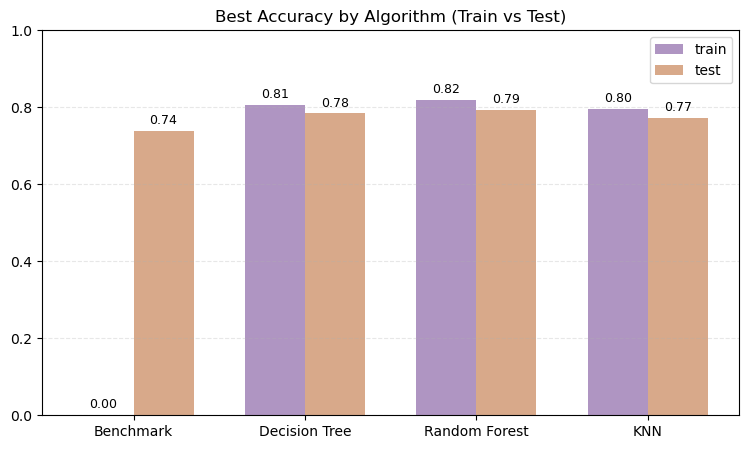

In [ ]:
plt.figure(figsize=(9, 5))
x = np.arange(len(summary))
width = 0.35

train_vals = summary['train_acc'].fillna(0).values
test_vals = summary['test_acc'].values

bars1 = plt.bar(x - width / 2, train_vals, width, label='train', color='#602D87', alpha=0.5)
bars2 = plt.bar(x + width / 2, test_vals, width, label='test', color='#B25516', alpha=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.2f}',
                 ha='center', va='bottom', fontsize=9)

plt.xticks(x, summary['algorithm'])
plt.ylim(0, 1)
plt.title("Best Accuracy by Algorithm (Train vs Test)")
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


### *Final Model Comparison & Business Conclusions*

In [ ]:

final_summary = pd.DataFrame([
    {'Model': 'Benchmark (predict majority)', 'Train Accuracy': '-', 'Test Accuracy': f'{benchmark_acc:.2%}', 'Notes': 'Predicts all customers stay'},
    {'Model': 'Decision Tree', 'Train Accuracy': f'{best_dt_row["train_acc"]:.2%}', 'Test Accuracy': f'{best_dt_row["test_acc"]:.2%}', 'Notes': best_dt_row['param']},
    {'Model': 'Random Forest', 'Train Accuracy': f'{best_rf_row["train_acc"]:.2%}', 'Test Accuracy': f'{best_rf_row["test_acc"]:.2%}', 'Notes': best_rf_row['param']},
    {'Model': 'KNN', 'Train Accuracy': f'{best_knn_row["train_acc"]:.2%}', 'Test Accuracy': f'{best_knn_row["test_acc"]:.2%}', 'Notes': best_knn_row['param']},
])

final_summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Model,Train Accuracy,Test Accuracy,Notes
Benchmark (predict majority),-,73.88%,Predicts all customers stay
Decision Tree,80.60%,78.42%,max_depth=5
Random Forest,81.98%,79.35%,"n_estimators=9, max_depth=7"
KNN,79.53%,77.22%,k=33


### *Key Business Insights*

Based on the analysis and model results, the following patterns were identified:

**1. Contract type is the strongest churn predictor**
Customers on month-to-month contracts churn significantly more than those on one- or two-year contracts.
→ *Recommendation: offer incentives to migrate short-term customers to longer contracts.*

**2. Fiber optic users show the highest churn rate**
Despite being a premium service, fiber optic customers are more likely to leave than DSL or no-internet customers.
→ *Recommendation: investigate service quality and pricing satisfaction among fiber optic users.*

**3. New customers are the highest-risk segment**
Customers with tenure under 12 months represent the most vulnerable group.
→ *Recommendation: invest in onboarding experience and early retention programs.*

**4. Random Forest outperforms all models**
With ~79% test accuracy and the best generalization (low overfitting gap), Random Forest was selected as the final model and applied to the Part B dataset of 24,000+ records.